In [1]:
import pandas as pd
import numpy as np
import os

# El código configura el formato general para los decimales
pd.options.display.float_format = '{:,.2f}'.format

# El script define la ruta de descargas y carga el archivo
ruta_archivo = os.path.join(r"C:\Users\patri\Downloads", "supermarket_sales.csv")
df = pd.read_csv(ruta_archivo, encoding='latin1', dtype={'ITEM_CODE': str})

# 1. Para ver los datos
print(df.head())
# 2. Para ver los nombres EXACTOS de las columnas (sin recortes)
print(df.columns.tolist())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity  Tax 5%  Total       Date  \
0       Health and beauty       74.69         7   26.14 548.97   1/5/2019   
1  Electronic accessories       15.28         5    3.82  80.22   3/8/2019   
2      Home and lifestyle       46.33         7   16.22 340.53   3/3/2019   
3       Health and beauty       58.22         8   23.29 489.05  1/27/2019   
4       Sports and travel       86.31         7   30.21 634.38   2/8/2019   

    Time      Payment   cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet 522.83                     4.76         26.14    9.10  
1  10:29         Cash  76.40    

In [4]:
# El programa calcula la estadística descriptiva para el precio unitario
media_precio = np.mean(df['Unit price'])
mediana_precio = np.median(df['Unit price'])
moda_precio = df['Unit price'].mode().values[0] # El cálculo de la moda se apoya en pandas

# El programa calcula la estadística descriptiva para la cantidad
media_cantidad = np.mean(df['Quantity'])
mediana_cantidad = np.median(df['Quantity'])
moda_cantidad = df['Quantity'].mode().values[0]

# El script imprime los resultados
print("--- Estadística Descriptiva ---")
print(f"Precio Unitario -> Media: {media_precio:,.2f}, Mediana: {mediana_precio:,.2f}, Moda: {moda_precio:,.2f}")
print(f"Cantidad -> Media: {media_cantidad:,.2f}, Mediana: {mediana_cantidad:,.2f}, Moda: {moda_cantidad:,.2f}")

--- Estadística Descriptiva ---
Precio Unitario -> Media: 55.67, Mediana: 55.23, Moda: 83.77
Cantidad -> Media: 5.51, Mediana: 5.00, Moda: 10.00


In [5]:
# El sistema obtiene el ticket promedio calculando la media de la columna Total

# 1) por ciudad
ticket_ciudad = df.groupby('City')['Total'].mean()

# 2) por product line y ciudad
ticket_prod_ciudad = df.groupby(['Product line', 'City'])['Total'].mean()

# 3) por género
ticket_genero = df.groupby('Gender')['Total'].mean()

# 4) por género y product line
ticket_gen_prod = df.groupby(['Gender', 'Product line'])['Total'].mean()

# El código imprime el primer cálculo como validación
print("--- Ticket Promedio por Ciudad ---")
print(ticket_ciudad)

--- Ticket Promedio por Ciudad ---
City
Mandalay    319.87
Naypyitaw   337.10
Yangon      312.35
Name: Total, dtype: float64


In [6]:
# El código calcula el total general de ventas para establecer los porcentajes
ventas_totales = df['Total'].sum()

# 1) Ventas por ciudad
ventas_ciudad = df.groupby('City')['Total'].sum().reset_index()
ventas_ciudad['Rank'] = ventas_ciudad['Total'].rank(ascending=False)
ventas_ciudad['% Aporte'] = (ventas_ciudad['Total'] / ventas_totales) * 100
top5_ciudad = ventas_ciudad[ventas_ciudad['Rank'] <= 5].sort_values('Rank')

# 2) Ventas por member (Customer type)
ventas_member = df.groupby('Customer type')['Total'].sum().reset_index()
ventas_member['Rank'] = ventas_member['Total'].rank(ascending=False)
ventas_member['% Aporte'] = (ventas_member['Total'] / ventas_totales) * 100
top5_member = ventas_member[ventas_member['Rank'] <= 5].sort_values('Rank')

# 3) Ventas por payment
ventas_payment = df.groupby('Payment')['Total'].sum().reset_index()
ventas_payment['Rank'] = ventas_payment['Total'].rank(ascending=False)
ventas_payment['% Aporte'] = (ventas_payment['Total'] / ventas_totales) * 100
top5_payment = ventas_payment[ventas_payment['Rank'] <= 5].sort_values('Rank')

# El sistema muestra las tablas generadas
print("--- Top 5 Ventas por Ciudad ---")
print(top5_ciudad, "\n")

print("--- Top 5 Ventas por Member (Customer type) ---")
print(top5_member, "\n")

print("--- Top 5 Ventas por Método de Pago ---")
print(top5_payment)

--- Top 5 Ventas por Ciudad ---
        City      Total  Rank  % Aporte
1  Naypyitaw 110,568.71  1.00     34.24
2     Yangon 106,200.37  2.00     32.88
0   Mandalay 106,197.67  3.00     32.88 

--- Top 5 Ventas por Member (Customer type) ---
  Customer type      Total  Rank  % Aporte
0        Member 164,223.44  1.00     50.85
1        Normal 158,743.30  2.00     49.15 

--- Top 5 Ventas por Método de Pago ---
       Payment      Total  Rank  % Aporte
0         Cash 112,206.57  1.00     34.74
2      Ewallet 109,993.11  2.00     34.06
1  Credit card 100,767.07  3.00     31.20


In [7]:
# El script extrae únicamente la hora de la transacción
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

# El sistema calcula la matriz de correlación entre hora y total
corr_hora_total = np.corrcoef(df['Hour'], df['Total'])

# El sistema calcula la matriz de correlación entre precio unitario y calificación
corr_precio_rating = np.corrcoef(df['Unit price'], df['Rating'])

# El programa imprime ambas matrices de correlación
print("Matriz de correlación (Hora vs Total):")
print(corr_hora_total, "\n")

print("Matriz de correlación (Precio Unitario vs Rating):")
print(corr_precio_rating)

Matriz de correlación (Hora vs Total):
[[ 1.         -0.00277044]
 [-0.00277044  1.        ]] 

Matriz de correlación (Precio Unitario vs Rating):
[[ 1.         -0.00877751]
 [-0.00877751  1.        ]]


# (Ignorar)

--- Tabla: Rendimiento por Sucursal ---
        City Branch  Total_Revenue  Total_Gross_Income  Total_Transactions  \
1  Naypyitaw      C     110,568.71            5,265.18                 328   
2     Yangon      A     106,200.37            5,057.16                 340   
0   Mandalay      B     106,197.67            5,057.03                 332   

   Avg_Rating  
1        7.07  
2        7.03  
0        6.82   



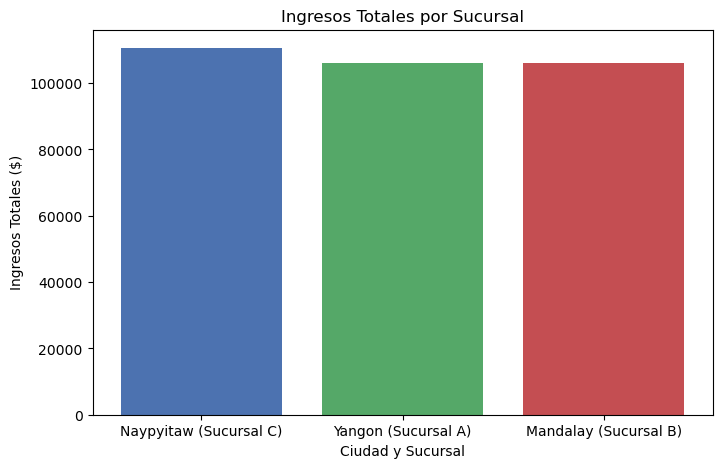

In [8]:
import matplotlib.pyplot as plt

# El código agrupa los datos por Ciudad y Sucursal, calculando las métricas solicitadas
rendimiento_sucursal = df.groupby(['City', 'Branch']).agg(
    Total_Revenue=('Total', 'sum'),
    Total_Gross_Income=('gross income', 'sum'),
    Total_Transactions=('Invoice ID', 'count'),
    Avg_Rating=('Rating', 'mean')
).reset_index()

# El sistema ordena la tabla por ingresos totales de mayor a menor
rendimiento_sucursal = rendimiento_sucursal.sort_values(by='Total_Revenue', ascending=False)

print("--- Tabla: Rendimiento por Sucursal ---")
print(rendimiento_sucursal, "\n")

# El script genera un gráfico de barras para visualizar los ingresos por sucursal
plt.figure(figsize=(8, 5))
plt.bar(rendimiento_sucursal['City'] + " (Sucursal " + rendimiento_sucursal['Branch'] + ")", 
        rendimiento_sucursal['Total_Revenue'], 
        color=['#4C72B0', '#55A868', '#C44E52'])

plt.title('Ingresos Totales por Sucursal')
plt.ylabel('Ingresos Totales ($)')
plt.xlabel('Ciudad y Sucursal')
plt.show()